# **IMPORT LIBRARIES**

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import VotingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib
import warnings
import xgboost
warnings.filterwarnings('ignore')
np.random.seed(42)

## Set Global Plot Style

In [2]:
PALETTE = ["#2a9d8f", "#e76f51", "#264653", "#e9c46a", "#f4a261"]
sns.set_palette(PALETTE)
plt.style.use("seaborn-whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.color': '#e0e0e0',
    'figure.facecolor': '#f5f5f5'
})

# **LOAD DATASETS**

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e7/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e7/test.csv')

print("Original train columns:", train.columns.tolist())

Original train columns: ['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']


## Clean column names

In [4]:
def clean_column_names(df):
    new_columns = []
    for col in df.columns:
        new_col = col.strip().replace(' ', '_').lower()
        new_col = re.sub(r'[^a-z0-9_]', '', new_col) 
        new_columns.append(new_col)
    df.columns = new_columns
    return df

train = clean_column_names(train)
test = clean_column_names(test)

print("Cleaned train columns:", train.columns.tolist())

Cleaned train columns: ['id', 'time_spent_alone', 'stage_fear', 'social_event_attendance', 'going_outside', 'drained_after_socializing', 'friends_circle_size', 'post_frequency', 'personality']


## Set key columns & TARGET DETECTION

In [5]:
id_col = 'id'
TARGET_COL = 'personality'

if TARGET_COL not in train.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in training data. Please check dataset columns.")

## Target mapping and cleaning

In [6]:
def map_personality_binary(value):
    value = str(value).lower().strip()
    if 'introvert' in value:
        return 1
    elif 'extrovert' in value:
        return 0 
    else:
        return np.nan

train[TARGET_COL] = train[TARGET_COL].apply(map_personality_binary)
train = train.dropna(subset=[TARGET_COL]) 

print(f"\nTraining set shape: {train.shape}")
print(f"Testing set shape: {test.shape}")
print("Target distribution (Training Data):")
print(train[TARGET_COL].value_counts(normalize=True))



Training set shape: (18524, 9)
Testing set shape: (6175, 8)
Target distribution (Training Data):
personality
0    0.739527
1    0.260473
Name: proportion, dtype: float64


# **EXPLORATORY DATA ANALYSIS (EDA)**

## Target Distribution

Target Variable Distribution


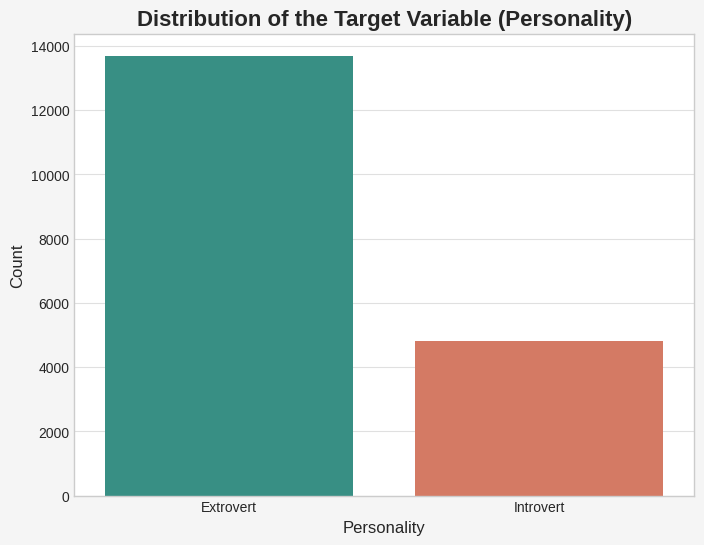

In [7]:
print("Target Variable Distribution")
plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET_COL, data=train, palette=PALETTE[:2])
plt.title('Distribution of the Target Variable (Personality)', fontsize=16)
plt.xlabel('Personality')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Extrovert', 'Introvert'])
plt.show()

## Define features and target column

In [8]:
cat_features_initial = ['time_spent_alone', 'stage_fear', 'social_event_attendance', 'going_outside',
                        'drained_after_socializing', 'friends_circle_size', 'post_frequency']
num_features_initial = cat_features_initial

## Numerical feature Analysis

Numerical Features Distribution


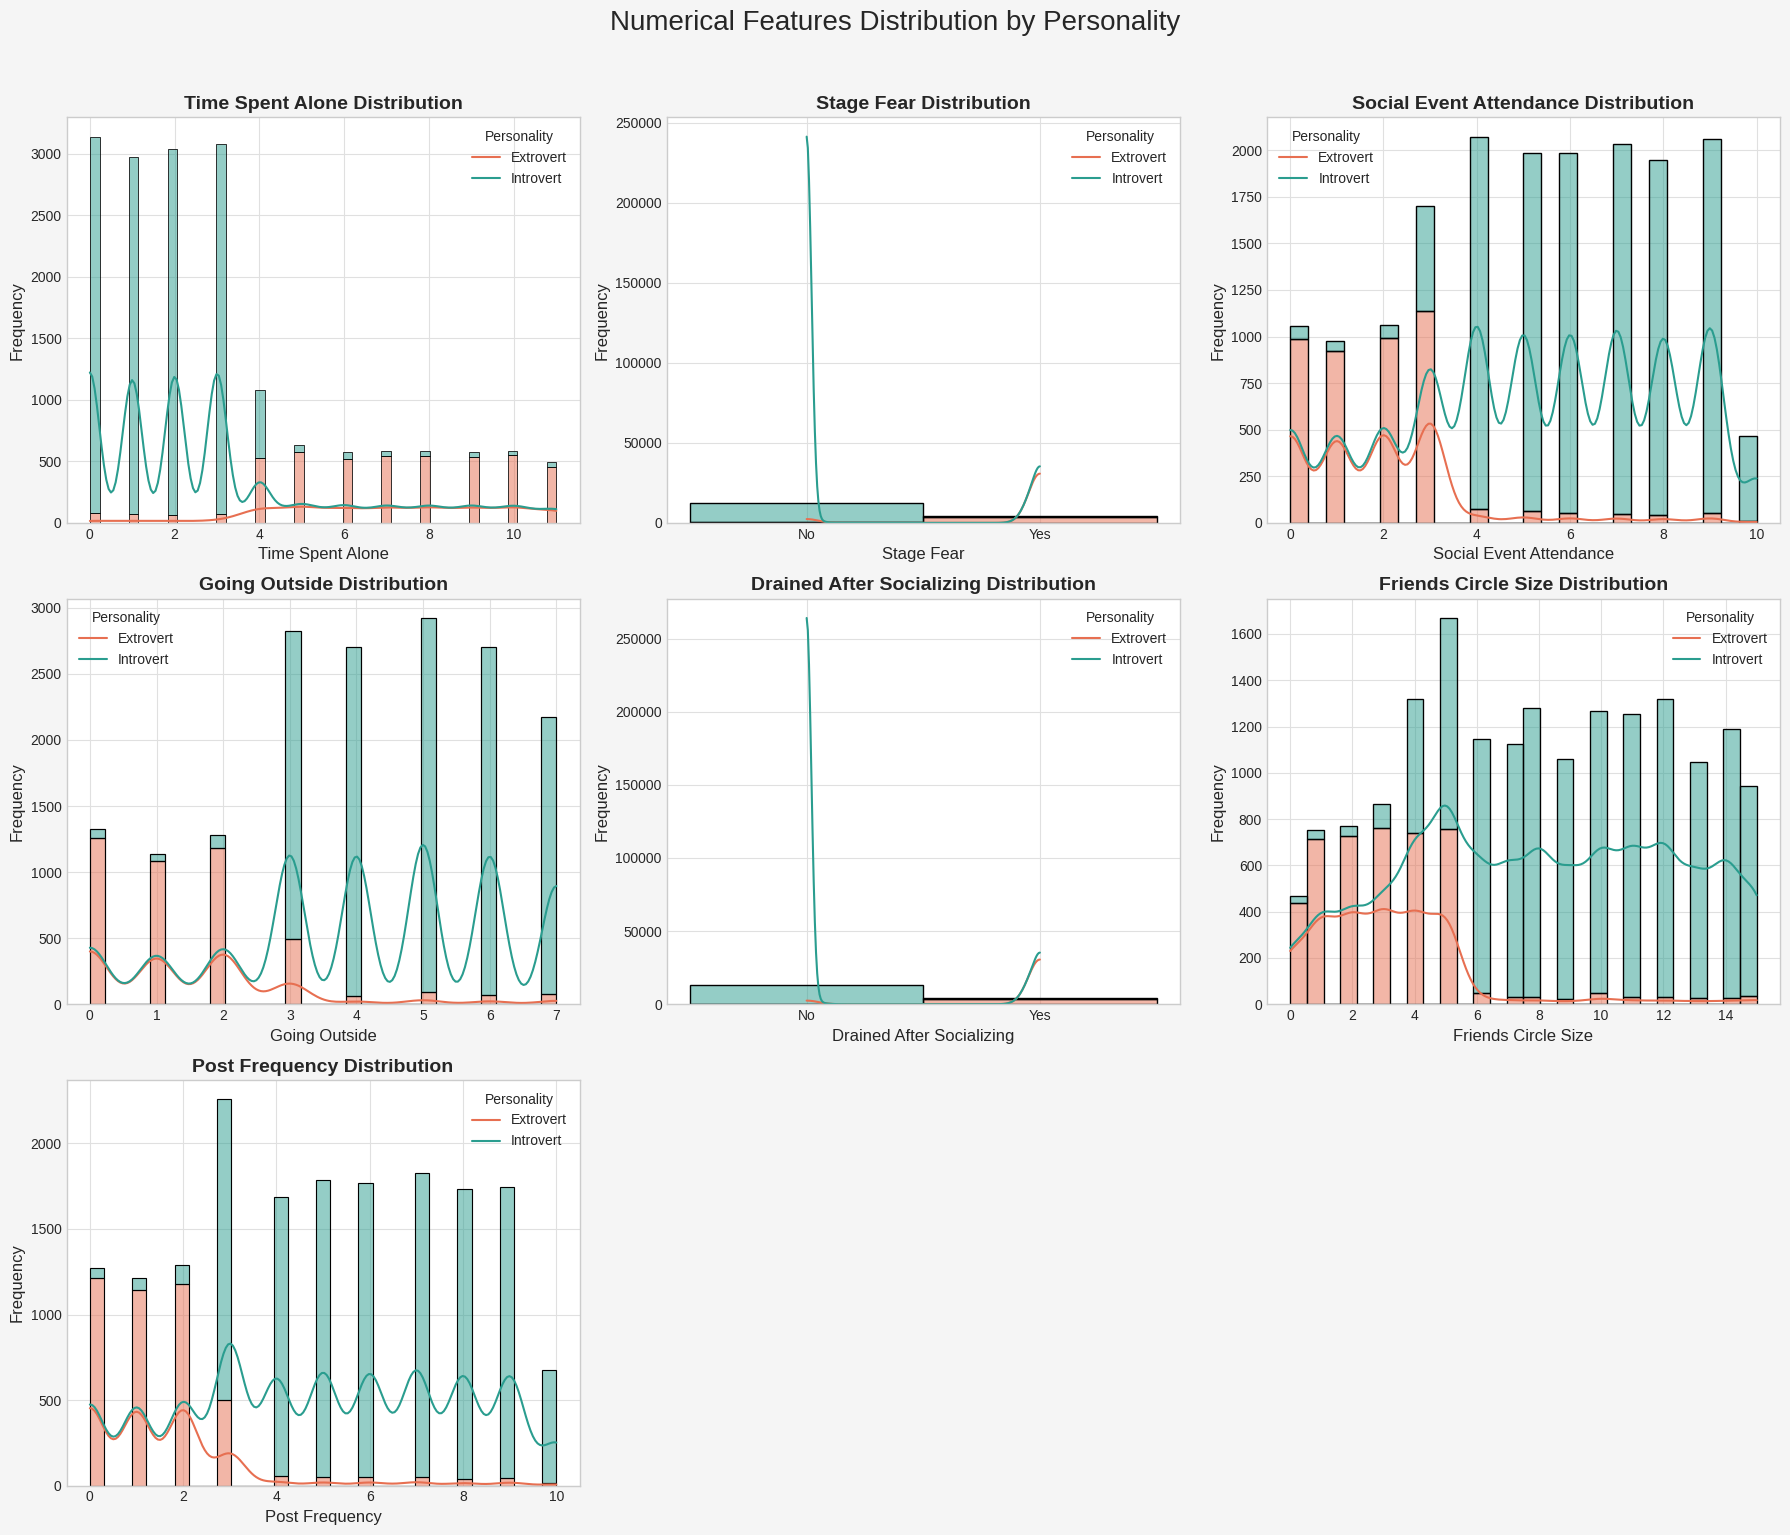

In [9]:
print("Numerical Features Distribution")
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Numerical Features Distribution by Personality', fontsize=20, y=1.02)
axes = axes.flatten()

for i, col in enumerate(num_features_initial):
    sns.histplot(data=train.dropna(subset=[col, TARGET_COL]),
                 x=col,
                 hue=TARGET_COL,
                 multiple="stack",
                 palette=PALETTE[:2],
                 ax=axes[i],
                 kde=True)
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=14)
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='Personality', labels=['Extrovert', 'Introvert'])

for i in range(len(num_features_initial), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Pair Plots of Numerical Features

Pair Plots of Numerical Features 


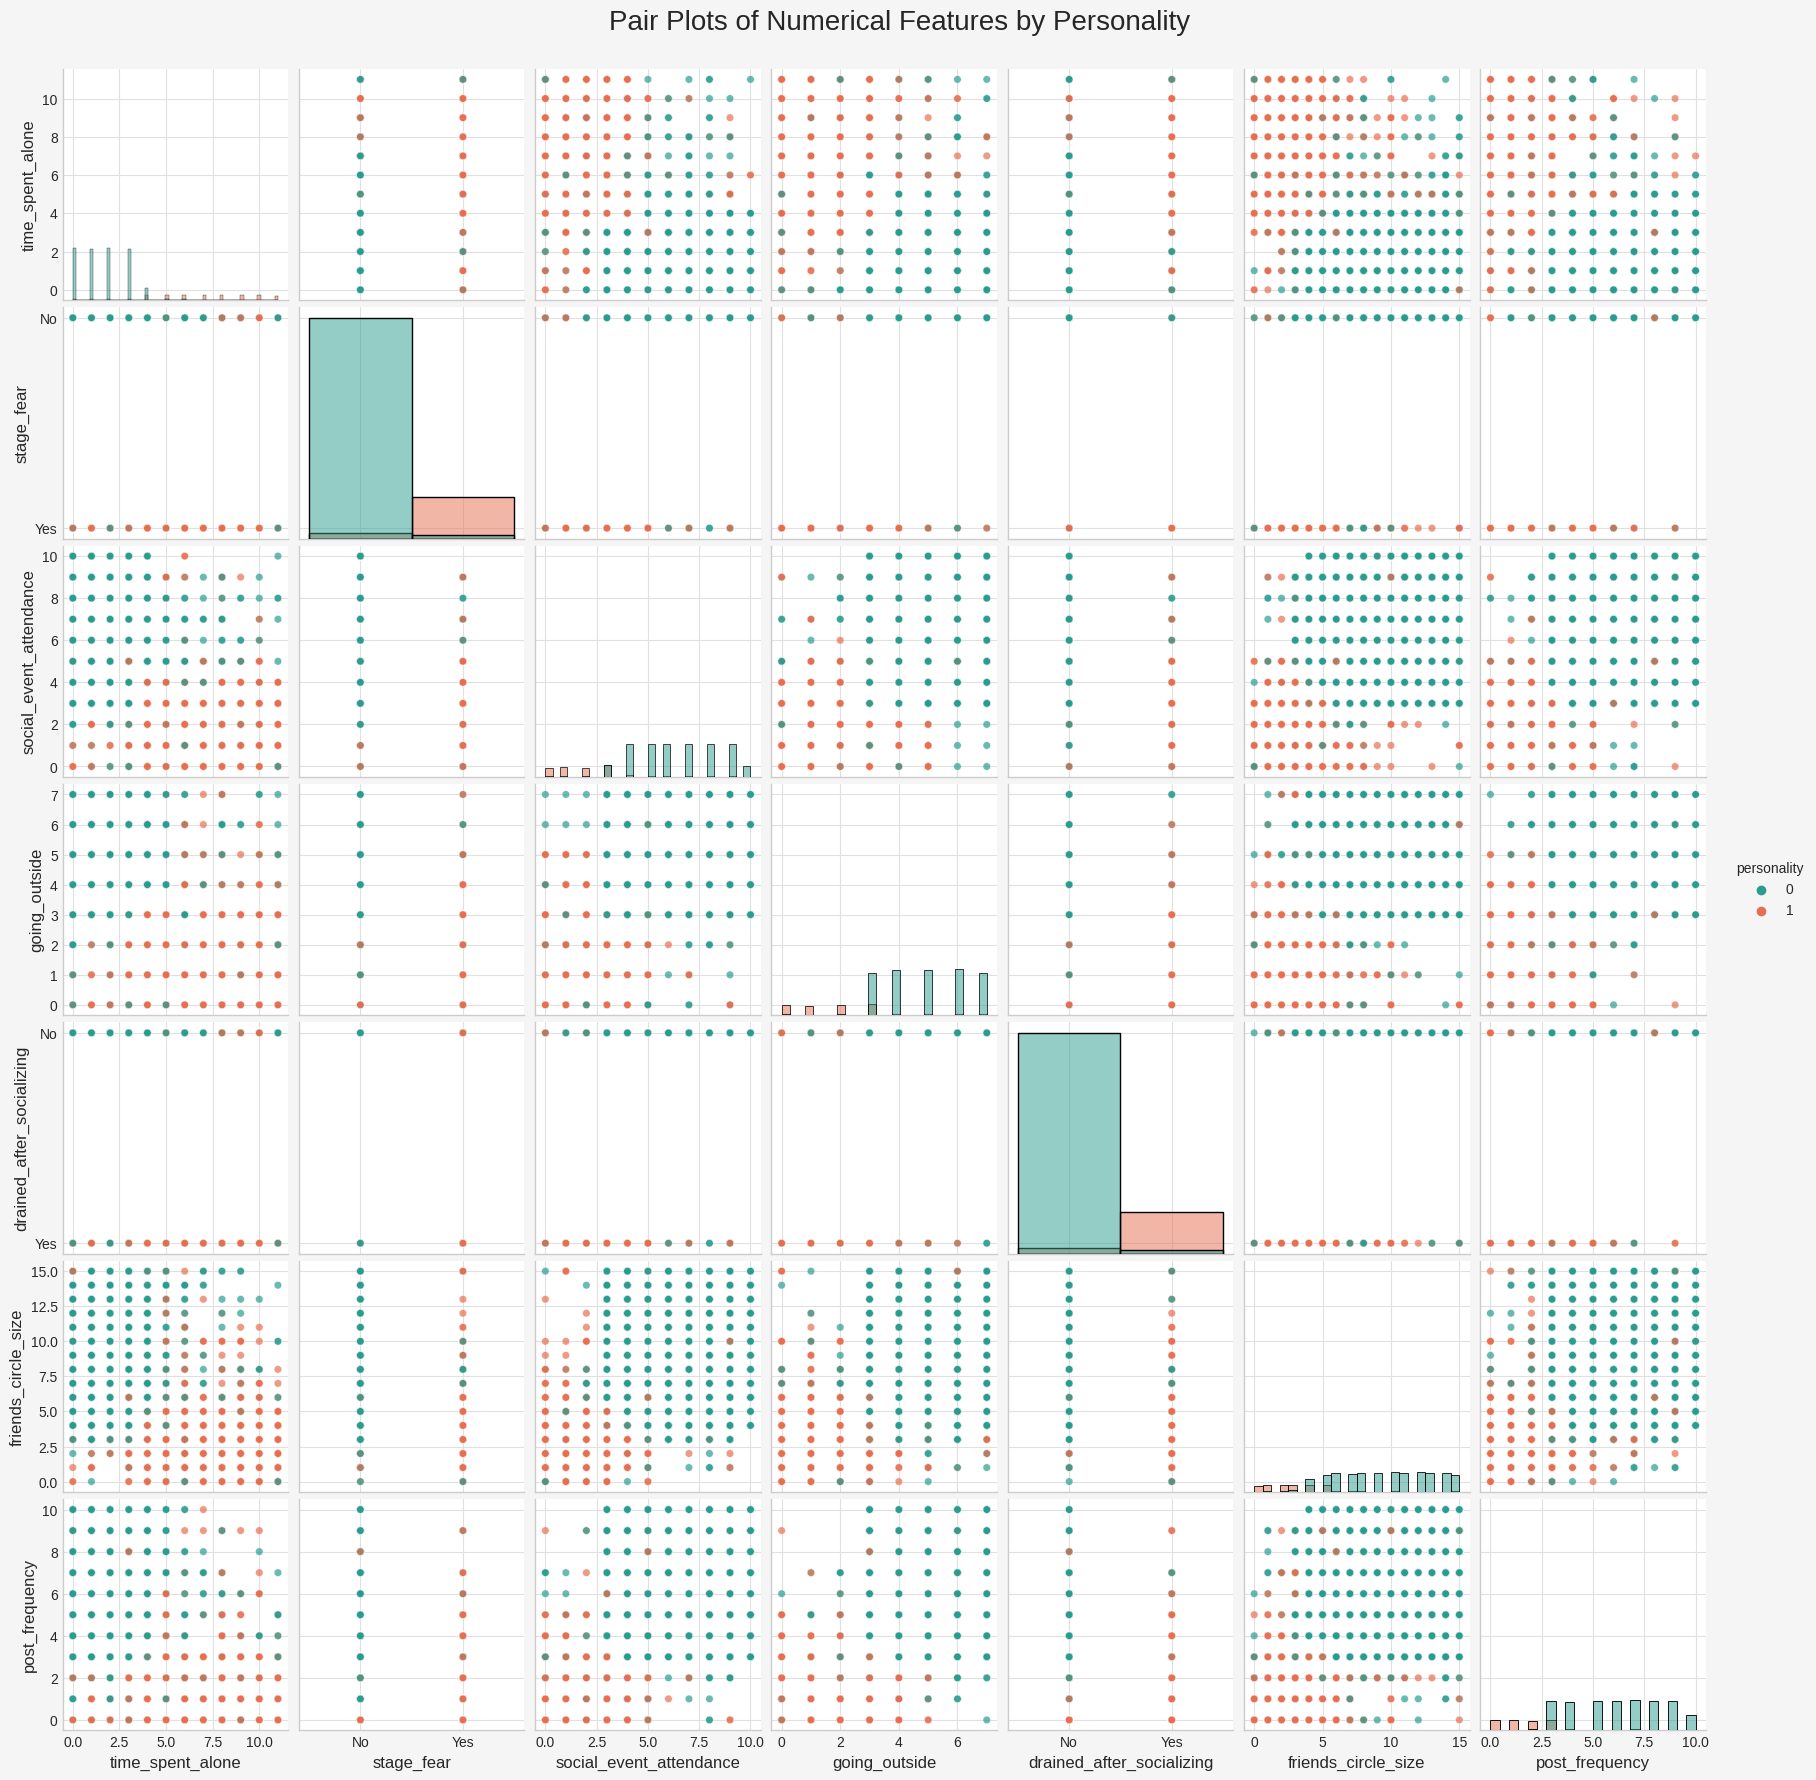

In [10]:
print("Pair Plots of Numerical Features ")
pair_plot = sns.pairplot(train.dropna(subset=num_features_initial + [TARGET_COL]),
                         hue=TARGET_COL,
                         vars=num_features_initial,
                         palette=PALETTE[:2],
                         diag_kind="hist", 
                         kind="scatter",
                         plot_kws={'alpha': 0.7, 's': 30})
pair_plot.fig.suptitle('Pair Plots of Numerical Features by Personality', y=1.02, fontsize=20)
sns.despine(top=True, right=True)
plt.show()

## Outlier Analysis using Box Plots

Outlier Analysis using Box Plots


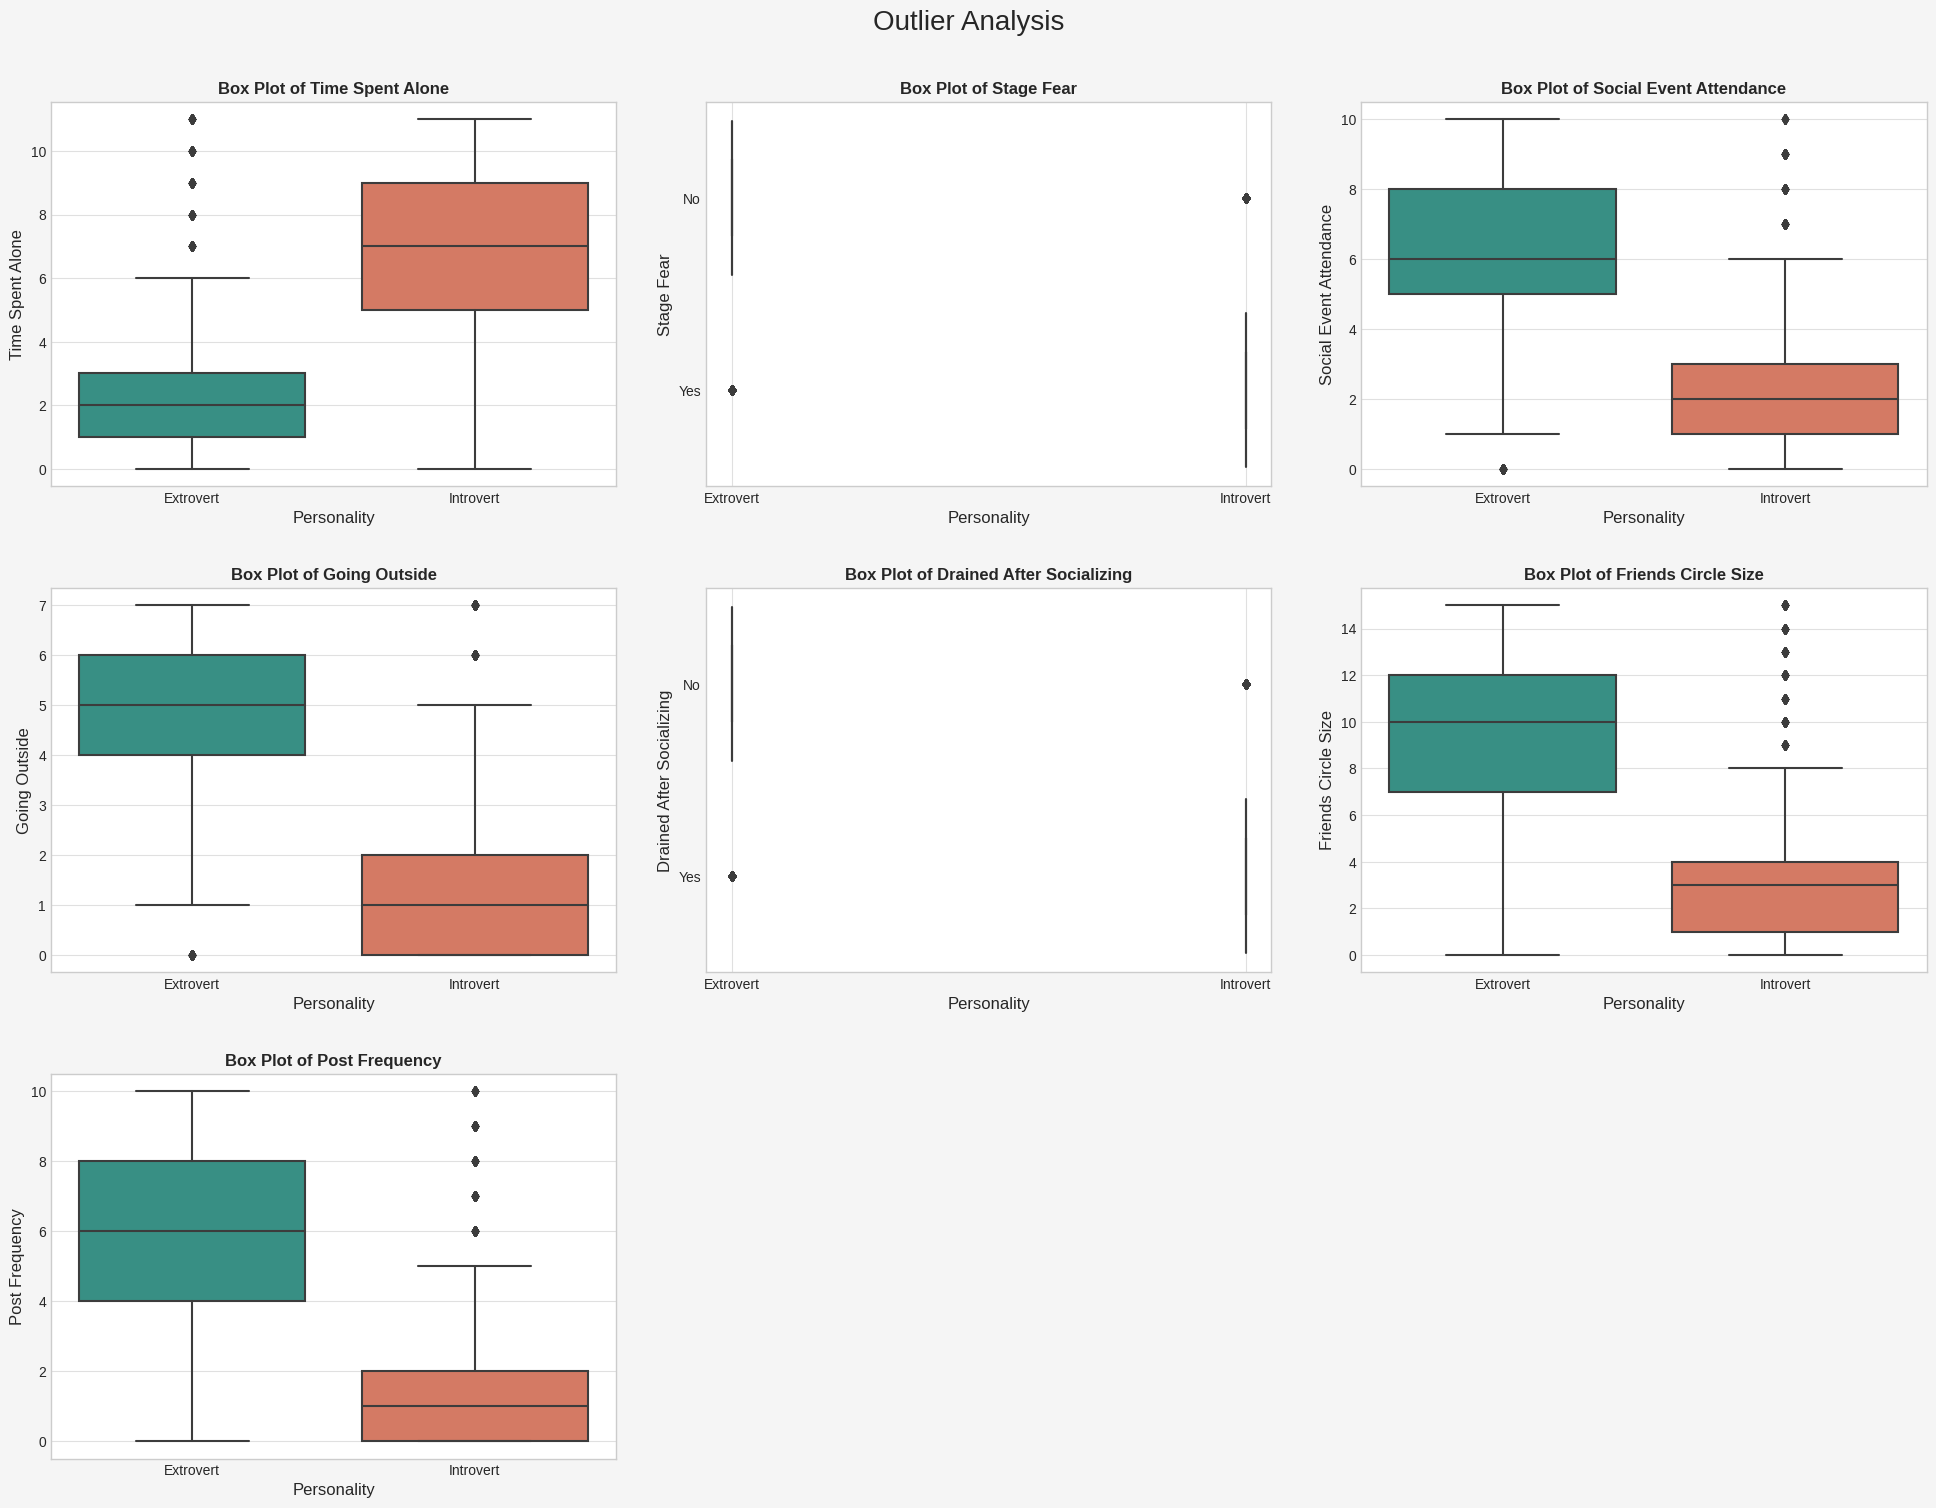

In [11]:
print("Outlier Analysis using Box Plots")
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_features_initial):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=TARGET_COL, y=col, data=train, palette=PALETTE[:2])
    plt.title(f'Box Plot of {col.title().replace("_", " ")}', fontsize=12)
    plt.xlabel('Personality')
    plt.ylabel(col.title().replace("_", " "))
    plt.xticks(ticks=[0, 1], labels=['Extrovert', 'Introvert'])
plt.tight_layout(pad=3.0)
plt.suptitle('Outlier Analysis', y=1.02, fontsize=20)
plt.show()

## Categorical Features Analysis

Categorical Features - Count Plots


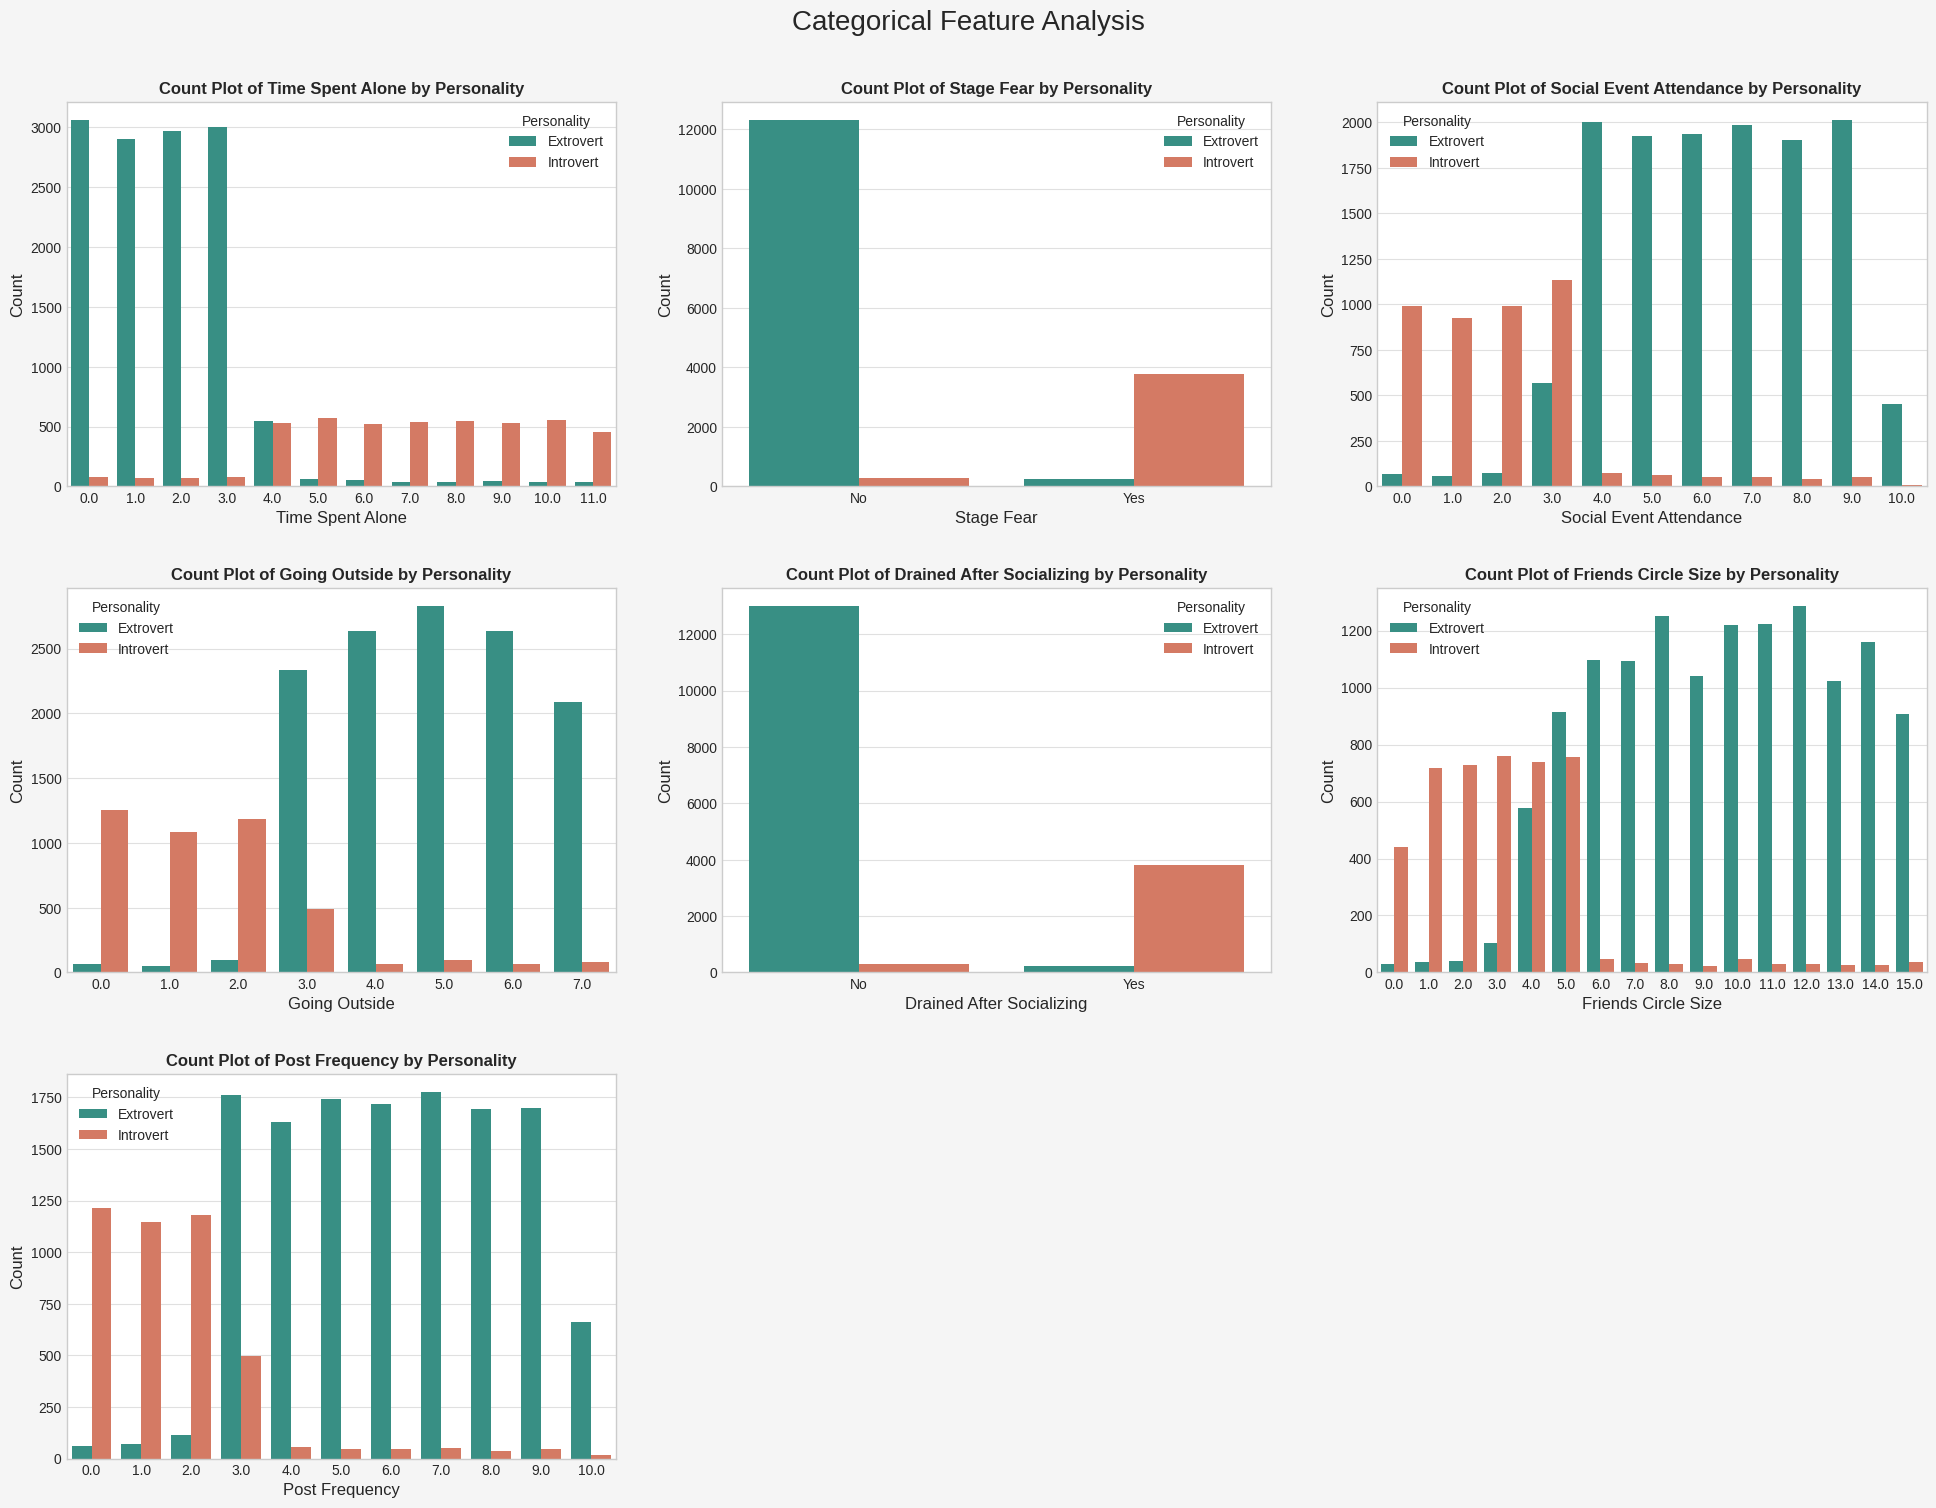

In [12]:
print("Categorical Features - Count Plots")
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_features_initial):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, hue=TARGET_COL, data=train, palette=PALETTE[:2])
    plt.title(f'Count Plot of {col.title().replace("_", " ")} by Personality', fontsize=12)
    plt.xlabel(col.title().replace("_", " "))
    plt.ylabel('Count')
    plt.legend(title='Personality', labels=['Extrovert', 'Introvert'])
plt.tight_layout(pad=3.0)
plt.suptitle('Categorical Feature Analysis', y=1.02, fontsize=20)
plt.show()

## Correlation Analysis

Correlation Analysis - Heatmap


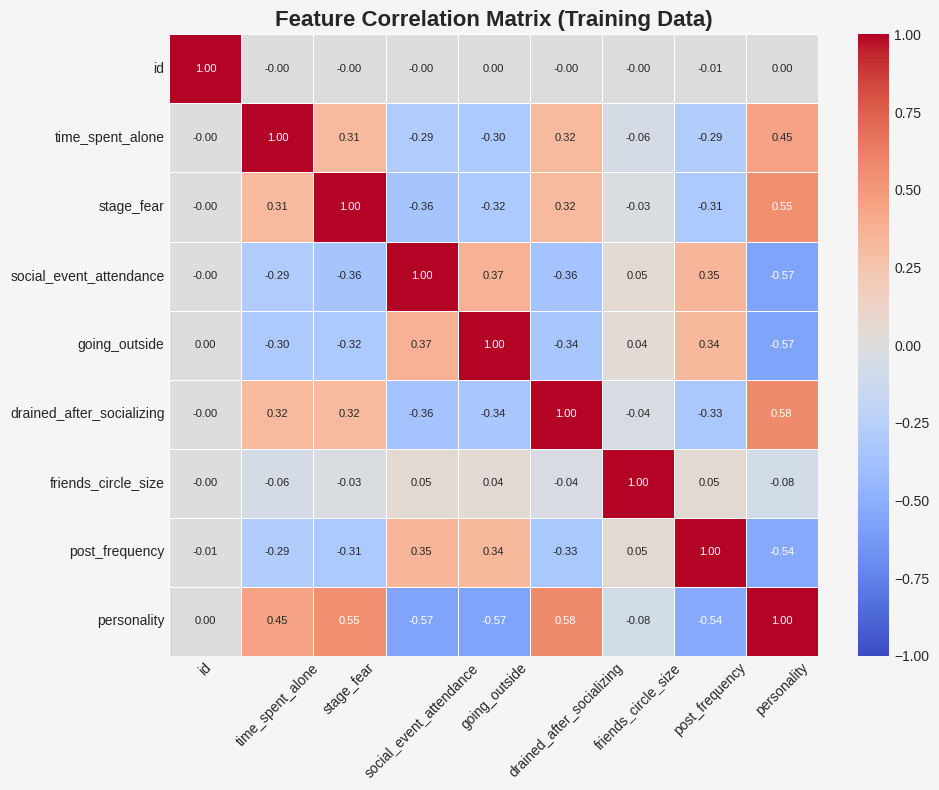

In [13]:
encoded_train = train.copy()
encoded_train[TARGET_COL] = encoded_train[TARGET_COL].astype(int) 

print("Correlation Analysis - Heatmap")
for col in cat_features_initial:
    if col in encoded_train.columns:
        le = LabelEncoder()
        encoded_train[col] = le.fit_transform(encoded_train[col].fillna('Missing').astype(str))

corr = encoded_train.corr(numeric_only=True) 
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot_kws={'size': 8}, linewidths=0.5)
plt.title('Feature Correlation Matrix (Training Data)', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **FEATURE ENGINEERING**

In [14]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_feature_names=None):
        self.numerical_feature_names = numerical_feature_names

    def fit(self, X, y=None):
        if self.numerical_feature_names is None and isinstance(X, pd.DataFrame):
            self.numerical_feature_names = X.columns.tolist()
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            if self.numerical_feature_names is None:
                raise ValueError("Feature names must be provided to FeatureEngineer when input is a NumPy array.")
            X_transformed = pd.DataFrame(X, columns=self.numerical_feature_names)
        else:
            X_transformed = X.copy()
        
        if 'time_spent_alone' in X_transformed.columns and 'social_event_attendance' in X_transformed.columns:
            X_transformed['time_social_interaction'] = X_transformed['time_spent_alone'] * X_transformed['social_event_attendance']
            X_transformed['social_alone_ratio'] = X_transformed['social_event_attendance'] / (X_transformed['time_spent_alone'] + 1e-8)

        if 'going_outside' in X_transformed.columns and 'friends_circle_size' in X_transformed.columns:
            X_transformed['outside_friends_interaction'] = X_transformed['going_outside'] * X_transformed['friends_circle_size']

        if 'post_frequency' in X_transformed.columns and 'friends_circle_size' in X_transformed.columns:
            X_transformed['post_friends_interaction'] = X_transformed['post_frequency'] * X_transformed['friends_circle_size']
            X_transformed['friend_post_ratio'] = X_transformed['friends_circle_size'] / (X_transformed['post_frequency'] + 1e-8)
        
        return X_transformed.values

## Custom Target Encoder Class

In [15]:
class CustomTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_feature_names=None):
        self.target_maps = {}
        self.categorical_feature_names = categorical_feature_names

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            if self.categorical_feature_names is None:
                raise ValueError("Categorical feature names must be provided to CustomTargetEncoder when input is a NumPy array.")
            X_df = pd.DataFrame(X, columns=self.categorical_feature_names)
        else:
            X_df = X.copy()

        for col in X_df.columns:
            target_mean = y.groupby(X_df[col].fillna('MissingCategory').astype(str)).mean()
            self.target_maps[col] = target_mean
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            if self.categorical_feature_names is None:
                raise ValueError("Categorical feature names must be provided to CustomTargetEncoder when input is a NumPy array.")
            X_df = pd.DataFrame(X, columns=self.categorical_feature_names)
        else:
            X_df = X.copy()

        X_transformed_df = X_df.copy()
        for col in X_transformed_df.columns:
            if col in self.target_maps:
                X_transformed_df[col] = X_transformed_df[col].fillna('MissingCategory').astype(str).map(self.target_maps[col]).fillna(0.5)
            else:
                X_transformed_df[col] = X_transformed_df[col].fillna(0.5)
        return X_transformed_df.values


## Prepare Data

In [16]:
X = train.drop(columns=[id_col, TARGET_COL], errors='ignore')
y = train[TARGET_COL]

numerical_features_for_ct = X.select_dtypes(include=np.number).columns.tolist()
categorical_features_for_ct = X.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical features for ColumnTransformer: {len(numerical_features_for_ct)}")
print(f"Categorical features for ColumnTransformer: {len(categorical_features_for_ct)}")


Numerical features for ColumnTransformer: 5
Categorical features for ColumnTransformer: 2


# **DATA PREPROCESSING**

## Define the numerical and categorical pipelines for the ColumnTransformer

In [17]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('feature_engineer', FeatureEngineer(numerical_feature_names=numerical_features_for_ct)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', CustomTargetEncoder(categorical_feature_names=categorical_features_for_ct))
])

## Define the ColumnTransformer that will be the first step in the final_pipeline

In [18]:
preprocessor_for_final_pipeline = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_for_ct),
        ('cat', categorical_transformer, categorical_features_for_ct)
    ],
    remainder='passthrough'
)

# **MODEL TRAINING WITH ENSEMBLE**

## Split data

In [19]:
X_train_optuna, X_val_optuna, y_train_optuna, y_val_optuna = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Define models

In [20]:
models_for_ensemble = {
    'lgbm': LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'xgb': XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'),
    'cat': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
}

## Ensemble model averaging probabilities

In [21]:
class EnsembleModel(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators=None, voting='soft', weights=None):
        self.estimators = estimators if estimators is not None else [
            ('lgbm', LGBMClassifier(random_state=42)),
            ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')),
            ('cat', CatBoostClassifier(random_state=42, verbose=0))
        ]
        self.voting = voting
        self.weights = weights
        self.ensemble_classifier = VotingClassifier(
            estimators=self.estimators,
            voting=self.voting,
            weights=self.weights
        )

    def fit(self, X, y):
        self.ensemble_classifier.fit(X, y)
        self.classes_ = self.ensemble_classifier.classes_
        return self

    def predict_proba(self, X):
        return self.ensemble_classifier.predict_proba(X)

    def predict(self, X):
        return self.ensemble_classifier.predict(X)

## Optuna objective function

In [22]:
def objective_wrapper(trial):
    X_train_trial, X_test_trial, y_train_trial, y_test_trial = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    trial_preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('feature_engineer', FeatureEngineer(numerical_feature_names=numerical_features_for_ct)),
                ('scaler', StandardScaler())
            ]), numerical_features_for_ct),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('target_encoder', CustomTargetEncoder(categorical_feature_names=categorical_features_for_ct))
            ]), categorical_features_for_ct)
        ],
        remainder='passthrough'
    )

    X_train_processed = trial_preprocessor.fit_transform(X_train_trial, y_train_trial)
    X_test_processed = trial_preprocessor.transform(X_test_trial)

    lgbm_params = {
        'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('lgbm_num_leaves', 20, 60),
        'max_depth': trial.suggest_int('lgbm_max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('lgbm_min_child_samples', 20, 50),
        'subsample': trial.suggest_float('lgbm_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('lgbm_colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('lgbm_reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('lgbm_reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbose': -1
    }

    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
        'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('xgb_gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('xgb_lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('xgb_alpha', 1e-8, 1.0, log=True),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

    cat_params = {
        'iterations': trial.suggest_int('cat_iterations', 50, 500),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('cat_depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1e-8, 10.0, log=True),
        'random_seed': 42,
        'verbose': 0
    }

    lgbm = LGBMClassifier(**lgbm_params)
    xgb = XGBClassifier(**xgb_params)
    cat = CatBoostClassifier(**cat_params)

    estimators_for_optuna = [
        ('lgbm', lgbm),
        ('xgb', xgb),
        ('cat', cat)
    ]

    weights = []
    for i in range(len(estimators_for_optuna)):
        weights.append(trial.suggest_float(f'weight_{i}', 0.1, 1.0))
    weights = np.array(weights)
    weights = weights / np.sum(weights)

    ensemble_optuna = EnsembleModel(estimators=estimators_for_optuna, voting='soft', weights=weights)
    
    ensemble_optuna.fit(X_train_processed, y_train_trial)

    y_pred_trial = ensemble_optuna.predict(X_test_processed)
    f1 = f1_score(y_test_trial, y_pred_trial)

    return f1

study = optuna.create_study(direction='maximize')
study.optimize(objective_wrapper, n_trials=25)

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

best_params = study.best_params

best_lgbm = LGBMClassifier(
    n_estimators=best_params['lgbm_n_estimators'],
    learning_rate=best_params['lgbm_learning_rate'],
    num_leaves=best_params['lgbm_num_leaves'],
    max_depth=best_params['lgbm_max_depth'],
    min_child_samples=best_params['lgbm_min_child_samples'],
    subsample=best_params['lgbm_subsample'],
    colsample_bytree=best_params['lgbm_colsample_bytree'],
    reg_alpha=best_params['lgbm_reg_alpha'],
    reg_lambda=best_params['lgbm_reg_lambda'],
    random_state=42,
    verbose=-1
)

best_xgb = XGBClassifier(
    n_estimators=best_params['xgb_n_estimators'],
    learning_rate=best_params['xgb_learning_rate'],
    max_depth=best_params['xgb_max_depth'],
    subsample=best_params['xgb_subsample'],
    colsample_bytree=best_params['xgb_colsample_bytree'],
    gamma=best_params['xgb_gamma'],
    reg_lambda=best_params['xgb_lambda'],
    alpha=best_params['xgb_alpha'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

best_cat = CatBoostClassifier(
    iterations=best_params['cat_iterations'],
    learning_rate=best_params['cat_learning_rate'],
    depth=best_params['cat_depth'],
    l2_leaf_reg=best_params['cat_l2_leaf_reg'],
    random_seed=42,
    verbose=0
)

best_weights = np.array([
    best_params[f'weight_{i}'] for i in range(3)
])
best_weights = best_weights / np.sum(best_weights)

final_ensemble = EnsembleModel(
    estimators=[('lgbm', best_lgbm), ('xgb', best_xgb), ('cat', best_cat)],
    voting='soft',
    weights=best_weights
)

[I 2025-07-30 11:56:29,097] A new study created in memory with name: no-name-afe121ef-c21b-4e73-bbe2-9f29ab2c2836
[I 2025-07-30 11:56:31,078] Trial 0 finished with value: 0.9442148760330579 and parameters: {'lgbm_n_estimators': 428, 'lgbm_learning_rate': 0.1652650931797681, 'lgbm_num_leaves': 45, 'lgbm_max_depth': 9, 'lgbm_min_child_samples': 27, 'lgbm_subsample': 0.796684926134704, 'lgbm_colsample_bytree': 0.7047408600827185, 'lgbm_reg_alpha': 1.1236507638371589e-08, 'lgbm_reg_lambda': 6.121452087710971e-07, 'xgb_n_estimators': 434, 'xgb_learning_rate': 0.1305021941313242, 'xgb_max_depth': 3, 'xgb_subsample': 0.7319365979966362, 'xgb_colsample_bytree': 0.8110522966973733, 'xgb_gamma': 1.8628306076418573e-08, 'xgb_lambda': 0.0009822538514516052, 'xgb_alpha': 0.000883026747815067, 'cat_iterations': 187, 'cat_learning_rate': 0.29639339673059717, 'cat_depth': 3, 'cat_l2_leaf_reg': 1.0536130327707356e-07, 'weight_0': 0.805317634148214, 'weight_1': 0.6589382794776538, 'weight_2': 0.75364065

Number of finished trials:  25
Best trial:
  Value:  0.9453044375644994
  Params: 
    lgbm_n_estimators: 376
    lgbm_learning_rate: 0.2988665711255662
    lgbm_num_leaves: 42
    lgbm_max_depth: 6
    lgbm_min_child_samples: 26
    lgbm_subsample: 0.9223286294054256
    lgbm_colsample_bytree: 0.7569086780473838
    lgbm_reg_alpha: 4.125411784782886e-07
    lgbm_reg_lambda: 0.10151101692648301
    xgb_n_estimators: 247
    xgb_learning_rate: 0.049523899675082514
    xgb_max_depth: 4
    xgb_subsample: 0.8829707448975957
    xgb_colsample_bytree: 0.86203025215061
    xgb_gamma: 0.09518623530702341
    xgb_lambda: 0.0006472655364704948
    xgb_alpha: 0.007119016121914139
    cat_iterations: 316
    cat_learning_rate: 0.02284737687947566
    cat_depth: 6
    cat_l2_leaf_reg: 1.4777766171237401e-08
    weight_0: 0.23789570772450375
    weight_1: 0.8593335350974922
    weight_2: 0.6280913565097082


## final_pipeline

In [23]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_for_final_pipeline),
    ('classifier', final_ensemble)
])

final_pipeline.fit(X, y)

print("Final pipeline trained successfully!")

Final pipeline trained successfully!


# **MODEL EVALUATION**

In [24]:
y_pred_full_train = final_pipeline.predict(X)
y_proba_full_train = final_pipeline.predict_proba(X)

print("\nClassification Report (Training Data):")
print(classification_report(y, y_pred_full_train, target_names=['Extrovert', 'Introvert']))


Classification Report (Training Data):
              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98     13699
   Introvert       0.95      0.94      0.94      4825

    accuracy                           0.97     18524
   macro avg       0.96      0.96      0.96     18524
weighted avg       0.97      0.97      0.97     18524



## Cross-validation

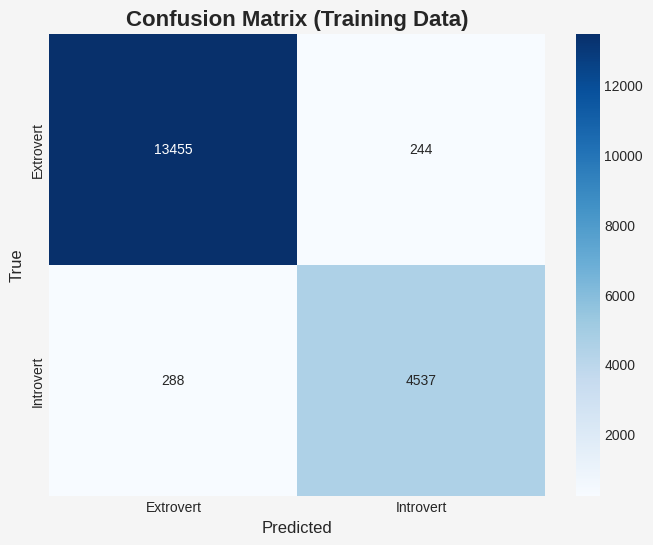

In [25]:
cm_train = confusion_matrix(y, y_pred_full_train)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Extrovert', 'Introvert'], 
            yticklabels=['Extrovert', 'Introvert']) 
plt.title('Confusion Matrix (Training Data)', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## ROC Curve and AUC (Training Data)

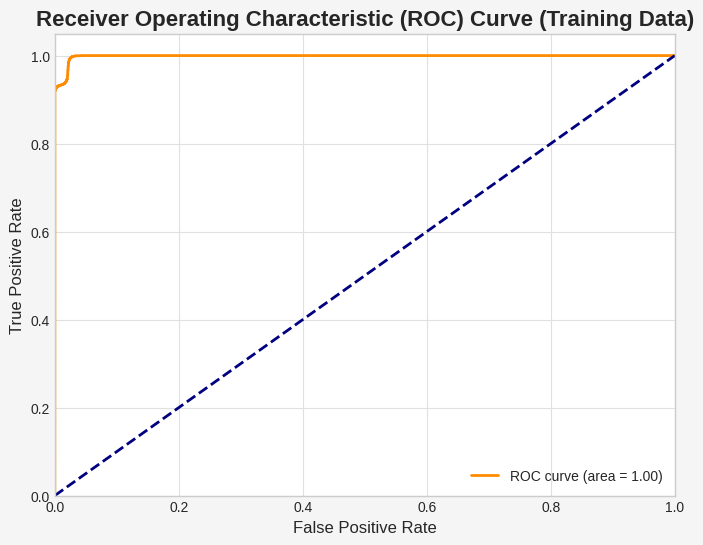

In [26]:
y_proba_positive_class_train = y_proba_full_train[:, 1] # Assuming Introvert is positive class (1)
fpr_train, tpr_train, _ = roc_curve(y, y_proba_positive_class_train)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_train:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Training Data)')
plt.legend(loc="lower right")
plt.show()

## Make predictions on the actual test dataset

In [27]:
test_predictions_encoded = final_pipeline.predict(test)
test_predictions_proba = final_pipeline.predict_proba(test)[:, 1] 

test_predictions_labels = np.array(['Introvert' if pred == 1 else 'Extrovert' for pred in test_predictions_encoded])

submission_df = pd.DataFrame({'id': test['id'], 'personality': test_predictions_labels})
submission_df.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")


Submission file 'submission.csv' created successfully!


# **Save model artifacts**

In [28]:
import os
output_dir = 'saved_models'
os.makedirs(output_dir, exist_ok=True)

artifacts = {
    'final_pipeline': final_pipeline,
    'id_col': id_col,
    'target_col': TARGET_COL,
    'target_label_map': {0: 'Extrovert', 1: 'Introvert'} 
}
joblib.dump(artifacts, os.path.join(output_dir, 'personality_predictor_artifacts.pkl')) 
print(f"Model artifacts saved as '{os.path.join(output_dir, 'personality_predictor_artifacts.pkl')}'")

Model artifacts saved as 'saved_models/personality_predictor_artifacts.pkl'


## Define a convenience prediction function for single inputs

In [29]:
def predict_personality(input_dict, artifacts_path='saved_models/personality_predictor_artifacts.pkl', threshold=0.5):
    loaded_artifacts = joblib.load(artifacts_path)
    loaded_pipeline = loaded_artifacts['final_pipeline'] 
    loaded_label_map = loaded_artifacts['target_label_map']
    
    df_input = pd.DataFrame([input_dict])
    
    def clean_input_cols(df):
        new_columns = []
        for col in df.columns:
            col_clean = re.sub(r'[^a-zA-Z0-9\s]', '', col.strip()).lower()
            col_clean = re.sub(r'\s+', '_', col_clean)
            new_columns.append(col_clean)
        df.columns = new_columns
        return df
    df_input = clean_input_cols(df_input)
    pipeline_initial_input_cols = [
        'time_spent_alone',
        'social_event_attendance',
        'going_outside',
        'friends_circle_size',
        'post_frequency',
        'stage_fear',
        'drained_after_socializing'
    ]
    
    for col in pipeline_initial_input_cols:
        if col not in df_input.columns:
            if col in ['time_spent_alone', 'social_event_attendance', 'going_outside', 'friends_circle_size', 'post_frequency']:
                df_input[col] = np.nan 
            elif col in ['stage_fear', 'drained_after_socializing']:
                df_input[col] = None 
            else:
                df_input[col] = np.nan 
    
    df_input_for_pipeline = df_input[pipeline_initial_input_cols]

    proba = loaded_pipeline.predict_proba(df_input_for_pipeline)[0]
    
    pred_class_binary = loaded_pipeline.predict(df_input_for_pipeline)[0]
    predicted_label = loaded_label_map.get(pred_class_binary, 'Unknown')
    
    confidence = proba[pred_class_binary]
    
    return predicted_label, confidence

## Example test for the personality model

In [30]:
sample_input_personality = {
    'id': 99999,
    'Time spent alone': 8.5,
    'Social event attendance': 1,
    'Going outside': 2,
    'Friends circle size': 5,
    'Post frequency': 1,
    'Stage fear': 'Yes',
    'Drained after socializing': 'Yes'
}

personality_prediction, personality_confidence = predict_personality(sample_input_personality)
print(f"\nSample Prediction (Personality):\nPersonality: {personality_prediction}\nConfidence: {personality_confidence:.2%}")


Sample Prediction (Personality):
Personality: Introvert
Confidence: 95.32%
